# 02: Accuracy Results

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import moocore

In [6]:
accuracy_df = pd.read_csv("results/accuracy_results.csv")
all_hwnas = pd.read_csv("results/all_hwnas.csv")

In [10]:
hwnas_cifar10 = all_hwnas[all_hwnas["dataset"] == "cifar10"]
hwnas_cifar10

,edgegpu_latency,edgegpu_energy,raspi4_latency,edgetpu_latency,pixel3_latency,eyeriss_latency,eyeriss_energy,eyeriss_arithmetic_intensity,fpga_latency,fpga_energy,...,seed,flop,test_acc,dataset,arch_0,arch_1,arch_2,arch_3,arch_4,arch_5
0,5.807419,24.226614,10.481977,0.957181,3.60585,3.64562,0.687283,6.289298,2.57296,18.01072,...,777,15.64737,85.62,cifar10,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect
1,5.807419,24.226614,10.481977,0.957181,3.60585,3.64562,0.687283,6.289298,2.57296,18.01072,...,888,15.64737,86.18,cifar10,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect
2,5.807419,24.226614,10.481977,0.957181,3.60585,3.64562,0.687283,6.289298,2.57296,18.01072,...,999,15.64737,85.79,cifar10,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect
9,6.547689,29.997148,54.777398,1.438988,17.23810,7.57778,1.564424,20.860067,5.31536,37.20752,...,777,113.95137,93.75,cifar10,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect
10,6.547689,29.997148,54.777398,1.438988,17.23810,7.57778,1.564424,20.860067,5.31536,37.20752,...,888,113.95137,93.62,cifar10,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110941,4.870882,21.552029,18.041367,-1.000000,8.25120,7.57778,1.458256,1.424774,2.77136,19.39952,...,888,7.78305,70.45,cifar10,none,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,none,avg_pool_3x3
110942,4.870882,21.552029,18.041367,-1.000000,8.25120,7.57778,1.458256,1.424774,2.77136,19.39952,...,999,7.78305,70.02,cifar10,none,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,none,avg_pool_3x3
110949,5.891724,26.294763,18.016671,0.646889,4.63185,2.66258,0.471955,11.627846,3.19376,22.35632,...,777,23.51169,85.62,cifar10,nor_conv_1x1,none,nor_conv_1x1,none,nor_conv_1x1,nor_conv_1x1
110950,5.891724,26.294763,18.016671,0.646889,4.63185,2.66258,0.471955,11.627846,3.19376,22.35632,...,888,23.51169,87.68,cifar10,nor_conv_1x1,none,nor_conv_1x1,none,nor_conv_1x1,nor_conv_1x1


In [20]:
accuracy_df_unique = accuracy_df.drop_duplicates()
accuracy_df_unique

,arch_idx,seed,dataset,accuracy_fp32,accuracy_esp
0,931,999,cifar10,58.62,12.31
1,1296,999,cifar10,74.01,30.33
2,113,999,cifar10,87.39,83.33
3,1184,999,cifar10,70.27,17.46
4,842,999,cifar10,92.01,91.79
...,...,...,...,...,...
41071,7045,999,cifar10,89.26,88.73
41097,7045,777,cifar10,89.63,89.06
41133,7045,888,cifar10,89.85,89.40
41219,8399,777,cifar10,93.16,93.02


In [45]:
merged_df = accuracy_df_unique.merge(hwnas_cifar10)
merged_df

,arch_idx,seed,dataset,accuracy_fp32,accuracy_esp,edgegpu_latency,edgegpu_energy,raspi4_latency,edgetpu_latency,pixel3_latency,...,fpga_energy,average_hw_metric,flop,test_acc,arch_0,arch_1,arch_2,arch_3,arch_4,arch_5
0,931,999,cifar10,58.62,12.31,4.005098,17.430188,8.384581,0.982212,4.69337,...,13.66512,3.007259e+05,7.78305,58.59,skip_connect,avg_pool_3x3,none,avg_pool_3x3,skip_connect,skip_connect
1,1296,999,cifar10,74.01,30.33,3.831038,16.668848,5.526350,0.678841,2.60226,...,10.79792,2.046298e+04,7.78305,74.03,skip_connect,skip_connect,skip_connect,none,none,avg_pool_3x3
2,113,999,cifar10,87.39,83.33,4.638934,20.193280,8.000759,0.845303,2.95332,...,14.40432,1.236957e+05,11.71521,87.40,skip_connect,skip_connect,nor_conv_1x1,none,avg_pool_3x3,skip_connect
3,1184,999,cifar10,70.27,17.46,3.436656,15.019905,15.213446,1.135898,6.46824,...,22.26672,6.422454e+06,7.78305,70.27,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,none
4,842,999,cifar10,92.01,91.79,3.929791,17.856972,18.787823,0.559505,8.05848,...,16.73392,4.951579e+05,43.17249,92.01,skip_connect,skip_connect,skip_connect,none,none,nor_conv_3x3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36875,7045,999,cifar10,89.26,88.73,3.726792,16.409067,5.035095,0.500014,2.36385,...,11.53712,5.039178e+03,11.71521,89.24,none,skip_connect,skip_connect,skip_connect,skip_connect,nor_conv_1x1
36876,7045,777,cifar10,89.63,89.06,3.726792,16.409067,5.035095,0.500014,2.36385,...,11.53712,5.039178e+03,11.71521,89.64,none,skip_connect,skip_connect,skip_connect,skip_connect,nor_conv_1x1
36877,7045,888,cifar10,89.85,89.40,3.726792,16.409067,5.035095,0.500014,2.36385,...,11.53712,5.039178e+03,11.71521,89.85,none,skip_connect,skip_connect,skip_connect,skip_connect,nor_conv_1x1
36878,8399,777,cifar10,93.16,93.02,7.192807,33.665934,60.417545,1.664686,25.98960,...,43.68112,3.005524e+09,117.88353,93.16,nor_conv_1x1,nor_conv_3x3,avg_pool_3x3,nor_conv_3x3,avg_pool_3x3,nor_conv_3x3


In [46]:
# Find missing values in each direction:
# merged_df = accuracy_df_unique.merge(hwnas_cifar10, how = "outer", indicator=True)
# merged_df[merged_df["_merge"] == "right_only"][["arch_idx", "seed"]].to_csv("missing.csv", index=False)
# merged_df[merged_df["_merge"] == "left_only"][["arch_idx", "seed"]].to_csv("extra.csv", index=False)

In [47]:
merged_df.sort_values(by = ["arch_idx", "seed"])

,arch_idx,seed,dataset,accuracy_fp32,accuracy_esp,edgegpu_latency,edgegpu_energy,raspi4_latency,edgetpu_latency,pixel3_latency,...,fpga_energy,average_hw_metric,flop,test_acc,arch_0,arch_1,arch_2,arch_3,arch_4,arch_5
131,0,777,cifar10,85.62,51.99,5.807419,24.226614,10.481977,0.957181,3.60585,...,18.01072,5.910059e+05,15.64737,85.62,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect
226,0,888,cifar10,86.18,61.69,5.807419,24.226614,10.481977,0.957181,3.60585,...,18.01072,5.910059e+05,15.64737,86.18,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect
10,0,999,cifar10,85.81,71.70,5.807419,24.226614,10.481977,0.957181,3.60585,...,18.01072,5.910059e+05,15.64737,85.79,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect
513,1,777,cifar10,93.75,93.08,6.547689,29.997148,54.777398,1.438988,17.23810,...,37.20752,6.257142e+08,113.95137,93.75,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect
654,1,888,cifar10,93.63,93.09,6.547689,29.997148,54.777398,1.438988,17.23810,...,37.20752,6.257142e+08,113.95137,93.62,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36244,15622,999,cifar10,93.21,93.15,5.351725,25.734660,52.712660,1.105549,22.56200,...,37.94672,3.116755e+08,117.88353,93.21,skip_connect,nor_conv_3x3,nor_conv_3x3,nor_conv_3x3,none,nor_conv_1x1
31597,15623,777,cifar10,69.48,10.81,4.870882,21.552029,18.041367,-1.000000,8.25120,...,19.39952,-9.284146e+06,7.78305,69.48,none,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,none,avg_pool_3x3
31665,15623,888,cifar10,70.45,33.53,4.870882,21.552029,18.041367,-1.000000,8.25120,...,19.39952,-9.284146e+06,7.78305,70.45,none,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,none,avg_pool_3x3
31730,15623,999,cifar10,70.00,12.96,4.870882,21.552029,18.041367,-1.000000,8.25120,...,19.39952,-9.284146e+06,7.78305,70.02,none,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,none,avg_pool_3x3


Magnitude of accuracy differences:

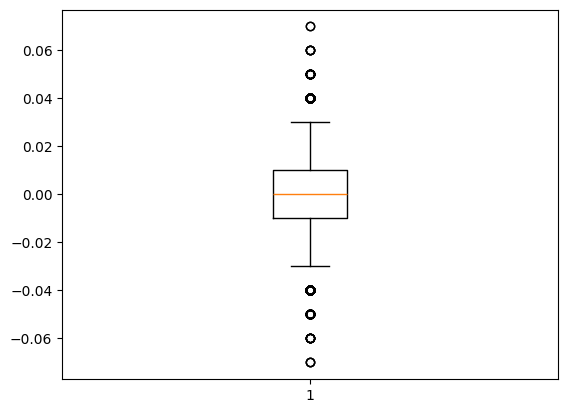

In [50]:
plt.boxplot(merged_df["test_acc"] - merged_df["accuracy_fp32"])
plt.show()

Does the type of architecture block influence performance degradation? No.

In [64]:
np.unique(merged_df[merged_df["accuracy_fp32"] - merged_df["accuracy_esp"] > 20][["arch_0", "arch_1", "arch_2", "arch_3", "arch_4", "arch_5"]].to_numpy(), return_counts=True)

(array(['avg_pool_3x3', 'none', 'nor_conv_1x1', 'nor_conv_3x3',
        'skip_connect'], dtype=object),
 array([13095, 10278,  7633,  6893, 10491]))

Does more FLOPs mean more performance degradation? No.

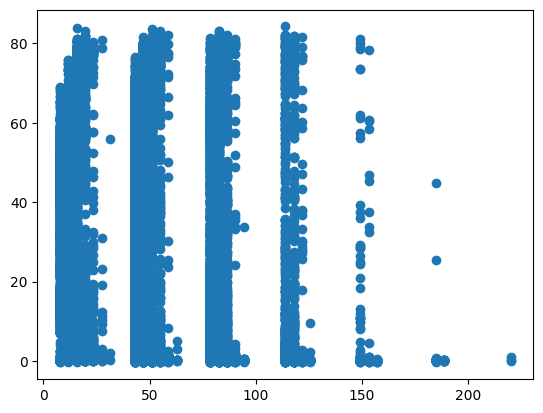

In [66]:
plt.scatter(merged_df["flop"], merged_df["accuracy_fp32"] - merged_df["accuracy_esp"])